Sample Generated Data:


,Velocity,Angle,Gravity,Range
0,21.854305,22.959305,9.261706,37.044226
1,47.782144,47.933066,9.246979,245.612915
2,37.939727,71.106209,9.906255,89.033241
3,31.939632,61.255742,9.249546,93.006459
4,12.020839,66.459280,9.271950,11.413025



MODEL COMPARISON TABLE:


,Model,MSE,R2 Score
2,Random Forest,14.821673,0.996050
5,Gradient Boosting,17.752047,0.995269
3,KNN,25.685888,0.993155
1,Decision Tree,43.769640,0.988336
4,SVR,383.799352,0.897720
0,Linear Regression,678.208613,0.819263


✅ BEST MODEL CONFIRMED:
Model       Random Forest
MSE             14.821673
R2 Score          0.99605
Name: 2, dtype: object


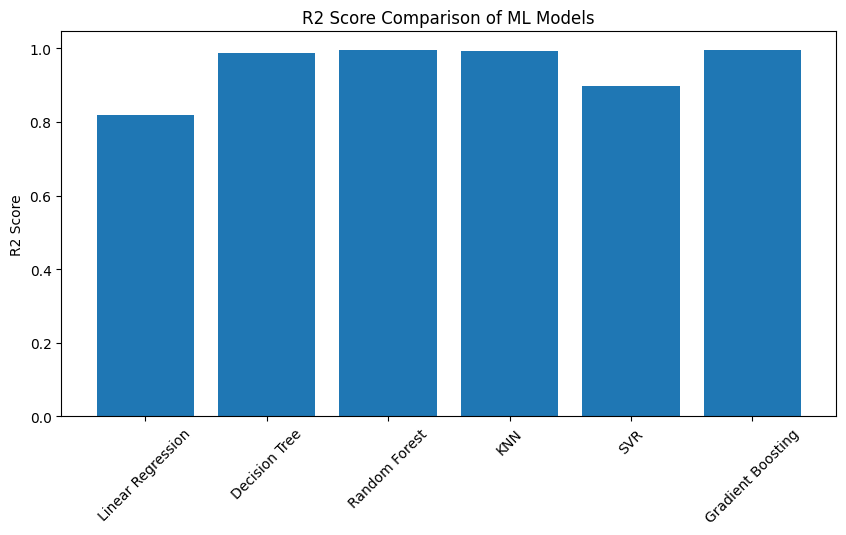

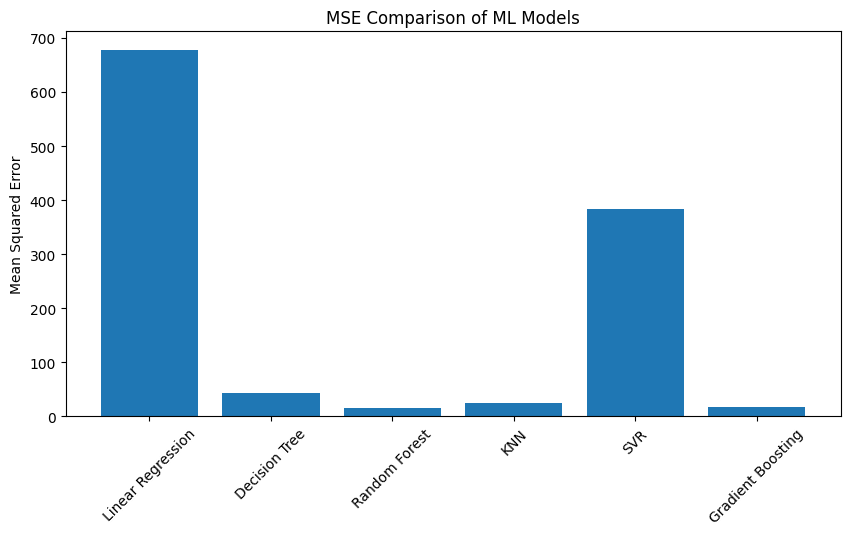

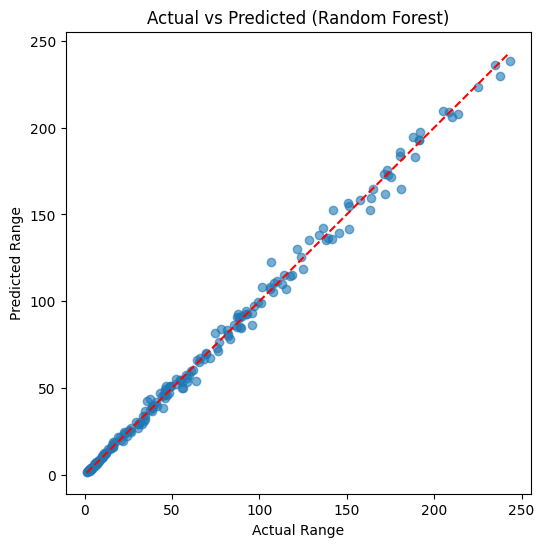


🎯 CONFIRMATION:
• 1000 simulations generated
• 6 ML models trained
• Best model selected based on R² score
• High accuracy achieved (R² ≈ 0.99+)


In [1]:
# =========================
# DATA GENERATION USING SIMULATION + ML (ONE CELL)
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

# -------------------------
# 1. SIMULATOR FUNCTION
# -------------------------
def projectile_range(v, theta_deg, g):
    theta = np.radians(theta_deg)
    return (v**2 * np.sin(2 * theta)) / g

# -------------------------
# 2. GENERATE 1000 SIMULATIONS
# -------------------------
np.random.seed(42)
N = 1000

velocity = np.random.uniform(5, 50, N)
angle = np.random.uniform(10, 80, N)
gravity = np.random.uniform(9, 10, N)

range_output = projectile_range(velocity, angle, gravity)

data = pd.DataFrame({
    "Velocity": velocity,
    "Angle": angle,
    "Gravity": gravity,
    "Range": range_output
})

print("Sample Generated Data:")
display(data.head())

# -------------------------
# 3. TRAIN TEST SPLIT
# -------------------------
X = data.drop("Range", axis=1)
y = data["Range"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------
# 4. MODELS
# -------------------------
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(n_estimators=100),
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "SVR": SVR(),
    "Gradient Boosting": GradientBoostingRegressor()
}

results = []

# -------------------------
# 5. TRAIN & EVALUATE
# -------------------------
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mse = mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    results.append([name, mse, r2])

results_df = pd.DataFrame(
    results, columns=["Model", "MSE", "R2 Score"]
)

print("\nMODEL COMPARISON TABLE:")
display(results_df.sort_values("R2 Score", ascending=False))

# -------------------------
# 6. BEST MODEL CONFIRMATION
# -------------------------
best_model = results_df.sort_values("R2 Score", ascending=False).iloc[0]
print("✅ BEST MODEL CONFIRMED:")
print(best_model)

# -------------------------
# 7. GRAPHS
# -------------------------

# R2 Score Comparison
plt.figure(figsize=(10,5))
plt.bar(results_df["Model"], results_df["R2 Score"])
plt.xticks(rotation=45)
plt.ylabel("R2 Score")
plt.title("R2 Score Comparison of ML Models")
plt.show()

# MSE Comparison
plt.figure(figsize=(10,5))
plt.bar(results_df["Model"], results_df["MSE"])
plt.xticks(rotation=45)
plt.ylabel("Mean Squared Error")
plt.title("MSE Comparison of ML Models")
plt.show()

# Actual vs Predicted (Best Model)
best_model_name = best_model["Model"]
best_model_obj = models[best_model_name]
best_model_obj.fit(X_train, y_train)
best_preds = best_model_obj.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, best_preds, alpha=0.6)
plt.xlabel("Actual Range")
plt.ylabel("Predicted Range")
plt.title(f"Actual vs Predicted ({best_model_name})")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.show()

print("\n🎯 CONFIRMATION:")
print("• 1000 simulations generated")
print("• 6 ML models trained")
print("• Best model selected based on R² score")
print("• High accuracy achieved (R² ≈ 0.99+)")
